In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch as t

from experiences.simple_nn import (
    SimpleNN,
    plot_dataset,
    prepare_2d_dataset,
    prepare_high_dim_dataset,
    train_model,
)
from experiences.verification import (
    compare_concrete_vs_abstract_propagation,
    verify_network_robustness,
    visualize_decision_boundary,
)
from zonotope.plot.theme import ORANGE, PINK, TURQUOISE, VIOLET

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[ORANGE, VIOLET, PINK, TURQUOISE])

In [ ]:
x_train, x_test, y_train, y_test, scaler_2d = prepare_2d_dataset()

input_dim = 2
hidden_dims = [10, 10]
output_dim = 2

model_2d = SimpleNN(input_dim, hidden_dims, output_dim)

losses, accuracies = train_model(model_2d, x_train, y_train, x_test, y_test, epochs=300)
x_test.shape

Training 2D model...
Epoch 0, Loss: 1.1576, Test Accuracy: 0.4300
Epoch 50, Loss: 0.2688, Test Accuracy: 0.8800
Epoch 100, Loss: 0.1469, Test Accuracy: 0.9600
Epoch 150, Loss: 0.0847, Test Accuracy: 0.9750
Epoch 200, Loss: 0.0710, Test Accuracy: 0.9900
Epoch 250, Loss: 0.0692, Test Accuracy: 0.9900
Final Test Accuracy: 0.9900


(200, 2)

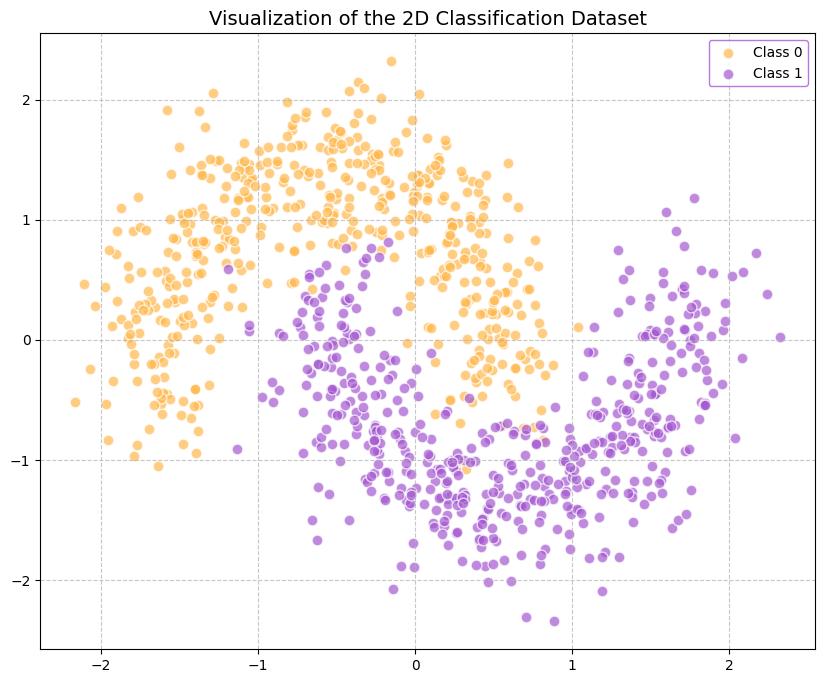

In [ ]:
plot_dataset(
    np.vstack([x_train, x_test]), np.concatenate([y_train, y_test]), "Moon dataset"
)

Point 1, epsilon=0.70: Not robust (margin: -7.1053)
Point 1, epsilon=0.60: Not robust (margin: -4.4499)
Point 1, epsilon=0.50: Not robust (margin: -1.8256)
Point 1, epsilon=0.40: Robust (margin: 0.7897)
Point 2, epsilon=0.70: Not robust (margin: -5.0814)
Point 2, epsilon=0.60: Not robust (margin: -3.4842)
Point 2, epsilon=0.50: Not robust (margin: -2.1591)
Point 2, epsilon=0.40: Not robust (margin: -1.1073)
Point 2, epsilon=0.30: Not robust (margin: -0.0086)
Point 2, epsilon=0.20: Robust (margin: 1.2439)
Point 3, epsilon=0.70: Not robust (margin: -1.0173)
Point 3, epsilon=0.60: Robust (margin: 1.5611)
Point 4, epsilon=0.70: Robust (margin: 0.2590)


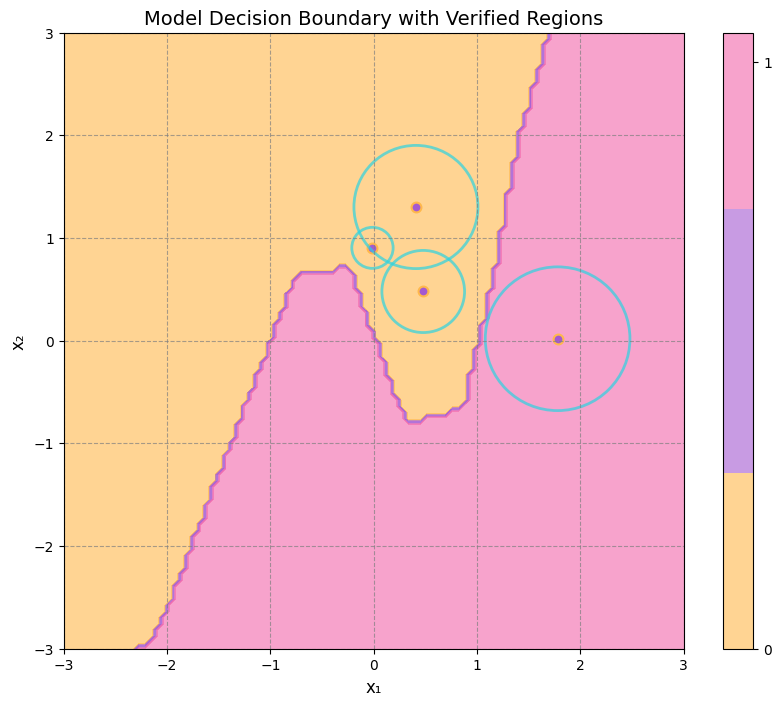

In [ ]:
epsilon_values = [0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
test_indices = [10, 50, 100, 150]
test_points = [t.tensor(x_test[i], dtype=t.float32) for i in test_indices]


# Verify robustness for each test sample
verified_points = []
for i, point in enumerate(test_points):
    with t.no_grad():
        output = model_2d(point)
        target_class = output.argmax().item()

    # Try big eps then reduce
    for eps in epsilon_values:
        is_robust, margin = verify_network_robustness(
            model_2d, point, eps, norm_type=2, target_class=target_class
        )
        print(
            f"Point {i + 1}, epsilon={eps:.2f}: {'Robust' if is_robust else 'Not robust'} (margin: {margin:.4f})"
        )

        # Only add the largest verified epsilon for each point
        if is_robust:
            verified_points.append((point, eps, True))
            break
    else:
        # If none of the epsilon work
        verified_points.append((point, epsilon_values[0], False))

visualize_decision_boundary(model_2d, verified_points=verified_points)


Point 1, epsilon=0.70: Not robust (margin: -8.8921)
Point 1, epsilon=0.60: Not robust (margin: -6.8336)
Point 1, epsilon=0.50: Not robust (margin: -3.9905)
Point 1, epsilon=0.40: Not robust (margin: -1.0121)
Point 1, epsilon=0.30: Robust (margin: 1.9635)
Point 2, epsilon=0.70: Not robust (margin: -6.7186)
Point 2, epsilon=0.60: Not robust (margin: -5.6567)
Point 2, epsilon=0.50: Not robust (margin: -4.4843)
Point 2, epsilon=0.40: Not robust (margin: -2.8701)
Point 2, epsilon=0.30: Not robust (margin: -1.3405)
Point 2, epsilon=0.20: Robust (margin: 0.3274)
Point 3, epsilon=0.70: Not robust (margin: -3.4637)
Point 3, epsilon=0.60: Robust (margin: 0.0135)
Point 4, epsilon=0.70: Not robust (margin: -2.2051)
Point 4, epsilon=0.60: Robust (margin: 0.1962)


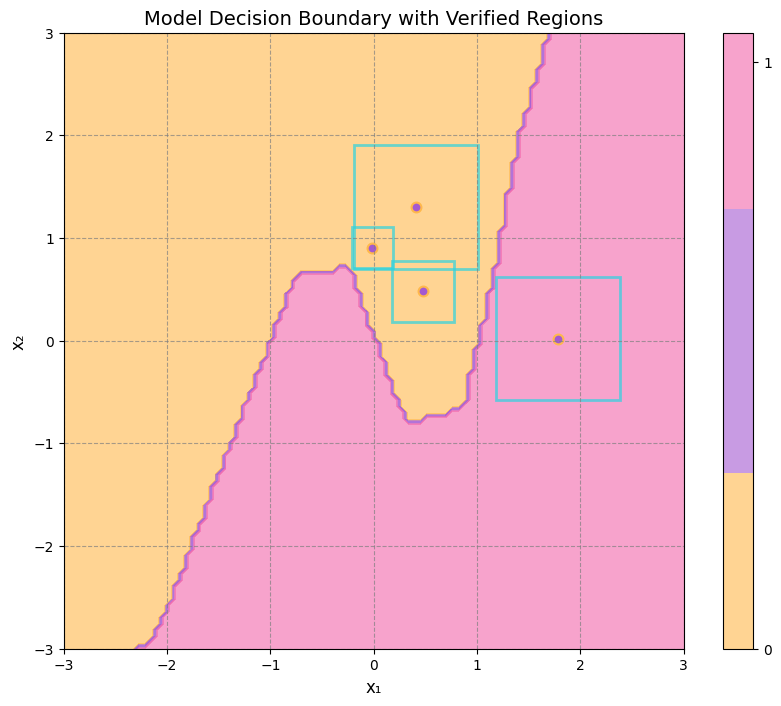

In [ ]:
# Same but inf norm
verified_points = []
for i, point in enumerate(test_points):
    with t.no_grad():
        output = model_2d(point)
        target_class = output.argmax().item()

    for eps in epsilon_values:
        is_robust, margin = verify_network_robustness(
            model_2d, point, eps, norm_type=float("inf"), target_class=target_class
        )
        print(
            f"Point {i + 1}, epsilon={eps:.2f}: {'Robust' if is_robust else 'Not robust'} (margin: {margin:.4f})"
        )

        if is_robust:
            verified_points.append((point, eps, True))
            break
    else:
        verified_points.append((point, epsilon_values[0], False))

visualize_decision_boundary(model_2d, verified_points=verified_points, norm="inf")


=== Experiment 2: Concrete vs Abstract Propagation ===
Training high-dimensional model...
Epoch 0, Loss: 1.3772, Test Accuracy: 0.3550
Epoch 50, Loss: 0.4272, Test Accuracy: 0.8200
Epoch 100, Loss: 0.2302, Test Accuracy: 0.8600
Epoch 150, Loss: 0.1656, Test Accuracy: 0.8700
Epoch 200, Loss: 0.1370, Test Accuracy: 0.8875
Epoch 250, Loss: 0.1133, Test Accuracy: 0.8850
Final Test Accuracy: 0.8850

L2 norm:


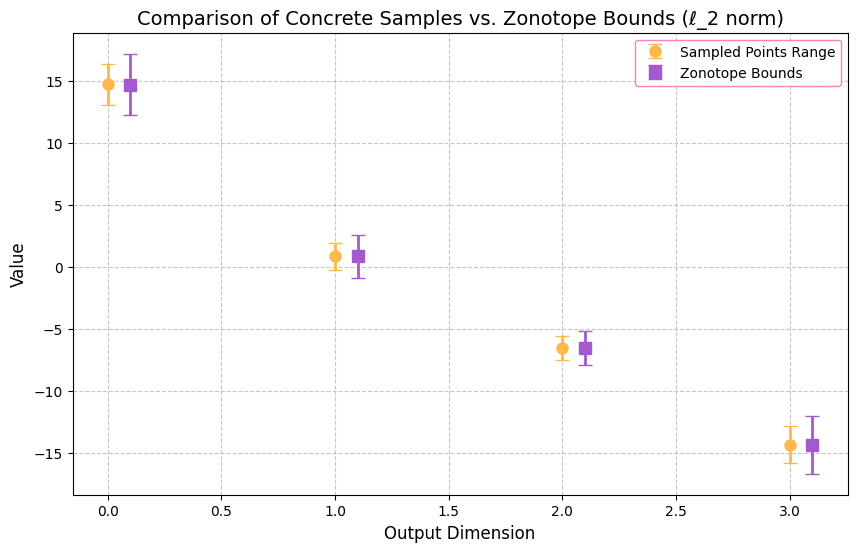

Average precision gap (zonotope width / sample width): 1.5227

L-infinity norm:


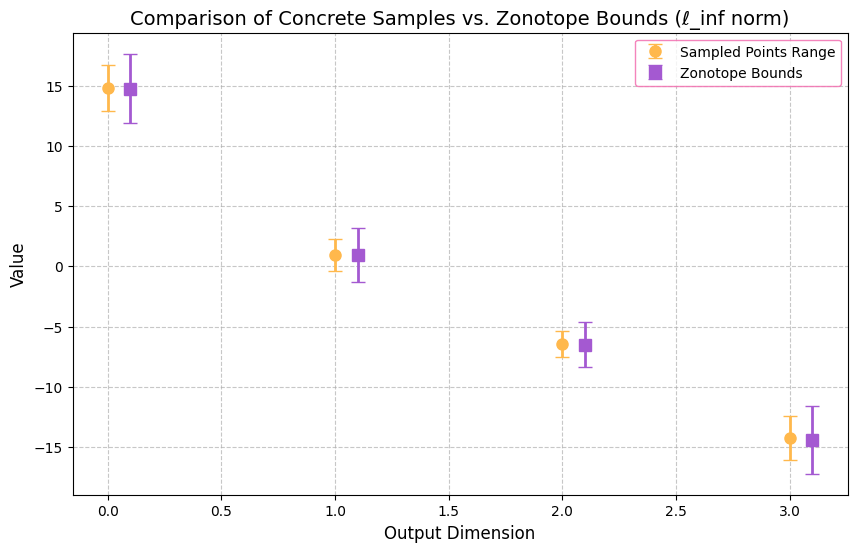

Average precision gap (zonotope width / sample width): 1.6353


(array([ 11.871956 ,  -1.3423753,  -8.402053 , -17.229486 ], dtype=float32),
 array([ 17.659826 ,   3.1963062,  -4.590162 , -11.57818  ], dtype=float32),
 array([ 12.904954  ,  -0.41053128,  -7.5602703 , -16.085684  ],
       dtype=float32),
 array([ 16.74389  ,   2.2538812,  -5.4148793, -12.447584 ], dtype=float32))

In [ ]:
# High dim
input_dim = 10
output_dim = 4
X_train_hd, X_test_hd, y_train_hd, y_test_hd, scaler_hd = prepare_high_dim_dataset(
    input_dim=input_dim, n_classes=output_dim
)

hidden_dims = [20, 10]
model_high_dim = SimpleNN(input_dim, hidden_dims, output_dim)

train_model(model_high_dim, X_train_hd, y_train_hd, X_test_hd, y_test_hd, epochs=300)

test_idx = 15  # Arbitrary test sample
input_point = t.tensor(X_test_hd[test_idx], dtype=t.float32)

# Test with L2 norm
print("\nL2 norm:")
compare_concrete_vs_abstract_propagation(
    model_high_dim, input_point, epsilon=0.2, norm_type=2, num_samples=1000
)

# Test with L-infinity norm
print("\nL-infinity norm:")
compare_concrete_vs_abstract_propagation(
    model_high_dim,
    input_point,
    epsilon=0.1,
    norm_type=float("inf"),
    num_samples=1000,
)
